In [53]:
from google.colab import drive
drive.mount('/content/drive')

!pip install prophet -q
!pip install shap -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from prophet import Prophet
from sklearn.metrics import classification_report
from xgboost import XGBClassifier
from sklearn.utils.class_weight import compute_sample_weight

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [54]:

path1 = "/content/drive/MyDrive/time_series_covid19_confirmed_global.csv"
df_jhu = pd.read_csv(path1)

# OWID dataset
path2 = "/content/drive/MyDrive/owid-covid-data.csv"
df_owid = pd.read_csv(path2)

print("JHU Shape:", df_jhu.shape)
print("OWID Shape:", df_owid.shape)

JHU Shape: (289, 1147)
OWID Shape: (429435, 67)


JHU DATASET

In [55]:

print(df_jhu.head())
print("\nShape:", df_jhu.shape)
print("\nColumns:", df_jhu.columns.tolist())
print("\nMissing Values:\n", df_jhu.isnull().sum())

print("=========================================")

date_columns = df_jhu.columns[4:]
print("First date:", date_columns[0])
print("Last date:", date_columns[-1])
print("Total days of data:", len(date_columns))
print("\nTotal countries:", df_jhu['Country/Region'].nunique())

  Province/State Country/Region       Lat       Long  1/22/20  1/23/20  \
0            NaN    Afghanistan  33.93911  67.709953        0        0   
1            NaN        Albania  41.15330  20.168300        0        0   
2            NaN        Algeria  28.03390   1.659600        0        0   
3            NaN        Andorra  42.50630   1.521800        0        0   
4            NaN         Angola -11.20270  17.873900        0        0   

   1/24/20  1/25/20  1/26/20  1/27/20  ...  2/28/23  3/1/23  3/2/23  3/3/23  \
0        0        0        0        0  ...   209322  209340  209358  209362   
1        0        0        0        0  ...   334391  334408  334408  334427   
2        0        0        0        0  ...   271441  271448  271463  271469   
3        0        0        0        0  ...    47866   47875   47875   47875   
4        0        0        0        0  ...   105255  105277  105277  105277   

   3/4/23  3/5/23  3/6/23  3/7/23  3/8/23  3/9/23  
0  209369  209390  209406  2

OWID DATASET

In [56]:
print(df_owid.head())
print("\nShape:", df_owid.shape)
print("\nColumns:", df_owid.columns.tolist())
print("\nMissing Values:\n", df_owid.isnull().sum())


print("=========================================")

print("Date range:", df_owid['date'].min(), "to", df_owid['date'].max())
print("Total countries:", df_owid['location'].nunique())
print("\nKey columns available:")
key_cols = ['location', 'date', 'total_cases', 'new_cases',
            'total_deaths', 'new_vaccinations', 'people_vaccinated',
            'total_tests', 'hosp_patients', 'population']
print(df_owid[key_cols].head(10))

  iso_code continent     location        date  total_cases  new_cases  \
0      AFG      Asia  Afghanistan  2020-01-05          0.0        0.0   
1      AFG      Asia  Afghanistan  2020-01-06          0.0        0.0   
2      AFG      Asia  Afghanistan  2020-01-07          0.0        0.0   
3      AFG      Asia  Afghanistan  2020-01-08          0.0        0.0   
4      AFG      Asia  Afghanistan  2020-01-09          0.0        0.0   

   new_cases_smoothed  total_deaths  new_deaths  new_deaths_smoothed  ...  \
0                 NaN           0.0         0.0                  NaN  ...   
1                 NaN           0.0         0.0                  NaN  ...   
2                 NaN           0.0         0.0                  NaN  ...   
3                 NaN           0.0         0.0                  NaN  ...   
4                 NaN           0.0         0.0                  NaN  ...   

   male_smokers  handwashing_facilities  hospital_beds_per_thousand  \
0           NaN            

**Data Cleaning**

In [57]:
# CLEAN JHU
jhu_melted = df_jhu.melt(
    id_vars=['Province/State', 'Country/Region', 'Lat', 'Long'],
    var_name='date',
    value_name='confirmed_cases'
)

# Convert date column to datetime
jhu_melted['date'] = pd.to_datetime(jhu_melted['date'], format='mixed')

# Group by country
jhu_country = jhu_melted.groupby(['Country/Region', 'date'])['confirmed_cases'].sum().reset_index()

print(jhu_country.shape)
print(jhu_country.head(10))

(229743, 3)
  Country/Region       date  confirmed_cases
0    Afghanistan 2020-01-22                0
1    Afghanistan 2020-01-23                0
2    Afghanistan 2020-01-24                0
3    Afghanistan 2020-01-25                0
4    Afghanistan 2020-01-26                0
5    Afghanistan 2020-01-27                0
6    Afghanistan 2020-01-28                0
7    Afghanistan 2020-01-29                0
8    Afghanistan 2020-01-30                0
9    Afghanistan 2020-01-31                0


In [58]:
# Select only columns we need
owid_cols = [
    'location', 'date', 'iso_code', 'continent',
    'new_cases', 'total_cases', 'new_deaths', 'total_deaths',
    'reproduction_rate', 'people_vaccinated_per_hundred',
    'people_fully_vaccinated_per_hundred',
    'total_tests_per_thousand', 'positive_rate',
    'hospital_beds_per_thousand', 'population',
    'population_density', 'median_age', 'gdp_per_capita',
    'stringency_index'
]

owid_clean = df_owid[owid_cols].copy()
owid_clean['date'] = pd.to_datetime(owid_clean['date'])

# Remove aggregated regions like 'World', 'Asia' etc
owid_clean = owid_clean[owid_clean['continent'].notna()]

print(owid_clean.shape)
print(owid_clean.isnull().sum())

(402910, 19)
location                                    0
date                                        0
iso_code                                    0
continent                                   0
new_cases                               12839
total_cases                             11194
new_deaths                              12390
total_deaths                            11194
reproduction_rate                      219169
people_vaccinated_per_hundred          337045
people_fully_vaccinated_per_hundred    339930
total_tests_per_thousand               323523
positive_rate                          306983
hospital_beds_per_thousand             113905
population                                  0
population_density                      44102
median_age                              69931
gdp_per_capita                          76302
stringency_index                       206720
dtype: int64


**Handling Missing Values**

In [59]:
# Forward fill per country
fill_cols = [
    'people_vaccinated_per_hundred',
    'people_fully_vaccinated_per_hundred',
    'total_tests_per_thousand',
    'positive_rate',
    'hospital_beds_per_thousand',
    'stringency_index',
    'population_density',
    'median_age',
    'gdp_per_capita'
]

owid_clean[fill_cols] = owid_clean.groupby('location')[fill_cols].transform(
    lambda x: x.ffill().bfill()
)

# Fill remaining new_cases / new_deaths nulls with 0
owid_clean['new_cases'] = owid_clean['new_cases'].fillna(0)
owid_clean['new_deaths'] = owid_clean['new_deaths'].fillna(0)
owid_clean['total_cases'] = owid_clean['total_cases'].fillna(0)
owid_clean['total_deaths'] = owid_clean['total_deaths'].fillna(0)

print("Missing after cleaning:")
print(owid_clean.isnull().sum())

Missing after cleaning:
location                                    0
date                                        0
iso_code                                    0
continent                                   0
new_cases                                   0
total_cases                                 0
new_deaths                                  0
total_deaths                                0
reproduction_rate                      219169
people_vaccinated_per_hundred           31807
people_fully_vaccinated_per_hundred     35155
total_tests_per_thousand                88746
positive_rate                          107168
hospital_beds_per_thousand             113905
population                                  0
population_density                      44102
median_age                              69931
gdp_per_capita                          76302
stringency_index                        92974
dtype: int64


**MERGING**

In [60]:

jhu_country = jhu_country.rename(columns={'Country/Region': 'location'})

# Merge on location + date
merged_df = pd.merge(
    owid_clean,
    jhu_country[['location', 'date', 'confirmed_cases']],
    on=['location', 'date'],
    how='left'
)

print("Merged shape:", merged_df.shape)
print(merged_df.head())

Merged shape: (402910, 20)
      location       date iso_code continent  new_cases  total_cases  \
0  Afghanistan 2020-01-05      AFG      Asia        0.0          0.0   
1  Afghanistan 2020-01-06      AFG      Asia        0.0          0.0   
2  Afghanistan 2020-01-07      AFG      Asia        0.0          0.0   
3  Afghanistan 2020-01-08      AFG      Asia        0.0          0.0   
4  Afghanistan 2020-01-09      AFG      Asia        0.0          0.0   

   new_deaths  total_deaths  reproduction_rate  people_vaccinated_per_hundred  \
0         0.0           0.0                NaN                            0.0   
1         0.0           0.0                NaN                            0.0   
2         0.0           0.0                NaN                            0.0   
3         0.0           0.0                NaN                            0.0   
4         0.0           0.0                NaN                            0.0   

   people_fully_vaccinated_per_hundred  total_tests_p

**Feature Eng.**


In [61]:
# Sorting
merged_df = merged_df.sort_values(['location', 'date']).reset_index(drop=True)

# 7-day and 14-day rolling average of new cases
merged_df['rolling_7day'] = merged_df.groupby('location')['new_cases'].transform(
    lambda x: x.rolling(7, min_periods=1).mean()
)

merged_df['rolling_14day'] = merged_df.groupby('location')['new_cases'].transform(
    lambda x: x.rolling(14, min_periods=1).mean()
)

# Rt estimation
merged_df['Rt'] = merged_df.groupby('location')['rolling_7day'].transform(
    lambda x: x / x.shift(7)
)
merged_df['Rt'] = merged_df['Rt'].clip(0, 5)
merged_df['Rt'] = merged_df['Rt'].fillna(1.0)

# Fix Rt for near-zero cases
merged_df.loc[merged_df['rolling_7day'] < 10, 'Rt'] = 1.0

# Daily growth rate
merged_df['growth_rate'] = merged_df.groupby('location')['total_cases'].transform(
    lambda x: x.pct_change().fillna(0)
)

# Doubling time (how fast cases double)
merged_df['doubling_time'] = 70 / (merged_df['growth_rate'] * 100).replace(0, np.nan)

# Cases per million
merged_df['cases_per_million'] = (
    merged_df['total_cases'] / merged_df['population']
) * 1_000_000


print(merged_df[['location', 'date', 'rolling_7day', 'growth_rate', 'doubling_time', 'cases_per_million']].head(10))




      location       date  rolling_7day  growth_rate  doubling_time  \
0  Afghanistan 2020-01-05           0.0          0.0            NaN   
1  Afghanistan 2020-01-06           0.0          0.0            NaN   
2  Afghanistan 2020-01-07           0.0          0.0            NaN   
3  Afghanistan 2020-01-08           0.0          0.0            NaN   
4  Afghanistan 2020-01-09           0.0          0.0            NaN   
5  Afghanistan 2020-01-10           0.0          0.0            NaN   
6  Afghanistan 2020-01-11           0.0          0.0            NaN   
7  Afghanistan 2020-01-12           0.0          0.0            NaN   
8  Afghanistan 2020-01-13           0.0          0.0            NaN   
9  Afghanistan 2020-01-14           0.0          0.0            NaN   

   cases_per_million  
0                0.0  
1                0.0  
2                0.0  
3                0.0  
4                0.0  
5                0.0  
6                0.0  
7                0.0  
8          

In [62]:
'''Instead of manually saying "if Rt > 1.5 → High risk"
We let the model LEARN from historical data:
"What combination of features actually predicted
a spike 14 days later?"'''

'Instead of manually saying "if Rt > 1.5 → High risk"\nWe let the model LEARN from historical data:\n"What combination of features actually predicted\na spike 14 days later?"'

In [63]:

# Future cases 14 days ahead
merged_df['future_cases_14d'] = merged_df.groupby('location')['rolling_7day'].transform(
    lambda x: x.shift(-14)
)

# Growth ratio over next 14 days
merged_df['future_growth'] = (
    merged_df['future_cases_14d'] / (merged_df['rolling_7day'] + 1)
)

# Target: 1 = outbreak incoming, 0 = stable/declining
def label_outbreak(row):
    if row['future_growth'] > 2.0:      # cases more than doubled
        return 2  # High
    elif row['future_growth'] > 1.3:    # 30% increase
        return 1  # Medium
    else:
        return 0  # Low

merged_df['outbreak_label'] = merged_df.apply(label_outbreak, axis=1)

# Lag features — what were cases 7, 14, 21 days ago?
merged_df['cases_7d_ago'] = merged_df.groupby('location')['rolling_7day'].transform(
    lambda x: x.shift(7)
)
merged_df['cases_14d_ago'] = merged_df.groupby('location')['rolling_7day'].transform(
    lambda x: x.shift(14)
)
merged_df['cases_21d_ago'] = merged_df.groupby('location')['rolling_7day'].transform(
    lambda x: x.shift(21)
)

# Acceleration — is growth speeding up or slowing down?
merged_df['acceleration'] = merged_df['rolling_7day'] - merged_df['rolling_14day']

# Death rate — proxy for variant severity
merged_df['death_rate'] = merged_df['new_deaths'] / (merged_df['new_cases'] + 1)

print("Label distribution:")
print(merged_df['outbreak_label'].value_counts())

Label distribution:
outbreak_label
0    327957
1     37827
2     37126
Name: count, dtype: int64


In [64]:


feature_cols = [
    'rolling_7day',
    'rolling_14day',
    'growth_rate',
    'Rt',
    'people_fully_vaccinated_per_hundred',
    'total_tests_per_thousand',
    'positive_rate',
    'hospital_beds_per_thousand',
    'population_density',
    'median_age',
    'stringency_index',
    'cases_per_million',
    "cases_7d_ago",
    "cases_14d_ago",
    "cases_21d_ago",
    "acceleration",
    "death_rate"
]

# Drop rows with NaN in features or label
model_df = merged_df[feature_cols + ['outbreak_label', 'date', 'location']].dropna()

# Remove future (after Aug 2024) — no labels available
model_df = model_df[model_df['date'] < '2024-07-01']

print("Model dataset shape:", model_df.shape)
print("Label distribution:\n", model_df['outbreak_label'].value_counts())

Model dataset shape: (203273, 20)
Label distribution:
 outbreak_label
0    155968
1     25397
2     21908
Name: count, dtype: int64


**EDA**


In [65]:


# Top 10 countries by total cases
latest = merged_df.groupby('location')['total_cases'].max().reset_index()
top10 = latest.sort_values('total_cases', ascending=False).head(10)

fig = px.bar(
    top10,
    x='location',
    y='total_cases',
    title='Top 10 Countries by Total COVID-19 Cases',
    color='total_cases',
    color_continuous_scale='Reds'
)
fig.show()

In [66]:
# Case trend for selected countries
countries = ['United States', 'India', 'Brazil', 'France', 'Germany']

trend_df = merged_df[merged_df['location'].isin(countries)]

fig = px.line(
    trend_df,
    x='date',
    y='rolling_7day',
    color='location',
    title='7-Day Rolling Average of New Cases',
    labels={'rolling_7day': 'New Cases (7-day avg)', 'date': 'Date'}
)
fig.show()

**Training**

In [67]:
X = model_df[feature_cols]
y = model_df['outbreak_label']

X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(0)

split_date = '2022-06-01'
train_mask = model_df['date'] < split_date
test_mask = model_df['date'] >= split_date

X_train, X_test = X[train_mask], X[test_mask]
y_train, y_test = y[train_mask], y[test_mask]



xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='mlogloss',
    random_state=42
)



sample_weights = compute_sample_weight(
    class_weight={0: 1, 1: 3, 2: 5},
    y=y_train
)

xgb_model.fit(X_train, y_train, sample_weight=sample_weights)

y_pred = xgb_model.predict(X_test)
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Low', 'Medium', 'High']))



Classification Report:
              precision    recall  f1-score   support

         Low       0.89      0.66      0.76     80430
      Medium       0.23      0.13      0.16      8901
        High       0.12      0.58      0.19      6334

    accuracy                           0.60     95665
   macro avg       0.41      0.45      0.37     95665
weighted avg       0.78      0.60      0.67     95665



In [68]:
importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)

print(importance_df)

fig = px.bar(
    importance_df,
    x='importance',
    y='feature',
    orientation='h',
    title='What Drives Outbreak Risk? — XGBoost Feature Importance',
    color='importance',
    color_continuous_scale='Reds'
)
fig.update_layout(yaxis={'categoryorder': 'total ascending'})
fig.show()

                                feature  importance
3                                    Rt    0.136411
15                         acceleration    0.116721
14                        cases_21d_ago    0.100537
13                        cases_14d_ago    0.064884
9                            median_age    0.058396
12                         cases_7d_ago    0.058249
1                         rolling_14day    0.052863
11                    cases_per_million    0.051222
4   people_fully_vaccinated_per_hundred    0.050908
10                     stringency_index    0.049405
0                          rolling_7day    0.046893
5              total_tests_per_thousand    0.046542
8                    population_density    0.043444
6                         positive_rate    0.043370
7            hospital_beds_per_thousand    0.042922
2                           growth_rate    0.027589
16                           death_rate    0.009644


In [69]:
# Early Warning System
'''Automatically scan ALL countries and flag ones
showing pre-outbreak warning signals RIGHT NOW'''


# Get latest data per country
latest_data = merged_df.sort_values('date').groupby('location').last().reset_index()

# Predict risk using XGBoost on latest data
latest_features = latest_data[feature_cols].replace([np.inf, -np.inf], np.nan).fillna(0)
latest_data['xgb_risk'] = xgb_model.predict(latest_features)
latest_data['xgb_risk_label'] = latest_data['xgb_risk'].map({
    0: 'Low', 1: 'Medium', 2: 'High'
})

# Early warning flag logic
def early_warning(row):
    signals = []

    if row['Rt'] > 1.2:
        signals.append('Rising Rt')
    if row['growth_rate'] > 0.03:
        signals.append('High Growth Rate')
    if row['people_fully_vaccinated_per_hundred'] < 30:
        signals.append('Low Vaccination')
    if row['positive_rate'] > 0.10:
        signals.append('High Positivity Rate')
    if row['rolling_7day'] > row['rolling_14day'] * 1.2:
        signals.append('Accelerating Cases')

    if len(signals) >= 2:
        return f"⚠️ {', '.join(signals)}"
    return "✅ Stable"

latest_data['warning'] = latest_data.apply(early_warning, axis=1)

# Countries with active warnings
warned = latest_data[latest_data['warning'].str.startswith('⚠️')][
    ['location', 'continent', 'Rt', 'growth_rate',
     'people_fully_vaccinated_per_hundred',
     'positive_rate', 'xgb_risk_label', 'warning']
].sort_values('xgb_risk_label', ascending=False)

print(f"⚠️ {len(warned)} countries flagged with early warnings\n")
print(warned.to_string())

⚠️ 11 countries flagged with early warnings

                   location      continent        Rt  growth_rate  people_fully_vaccinated_per_hundred  positive_rate xgb_risk_label                                                 warning
110                   Kenya         Africa  1.000000     0.000000                                20.53           0.11            Low                ⚠️ Low Vaccination, High Positivity Rate
120                   Libya         Africa  1.000000     0.000000                                18.15           0.25            Low                ⚠️ Low Vaccination, High Positivity Rate
226                 Ukraine         Europe  1.943182     0.000031                                39.65           0.60            Low  ⚠️ Rising Rt, High Positivity Rate, Accelerating Cases
2                   Algeria         Africa  1.000000     0.000066                                14.43            NaN           High                  ⚠️ Low Vaccination, Accelerating Cases
26   Bosni

In [70]:
# Warning count by continent
warning_continent = latest_data[latest_data['warning'].str.startswith('⚠️')]\
    .groupby('continent').size().reset_index(name='warned_countries')

fig = px.bar(
    warning_continent,
    x='continent',
    y='warned_countries',
    title='⚠️ Early Warning Flags by Continent',
    color='warned_countries',
    color_continuous_scale='Oranges'
)
fig.show()

# World map of warnings
fig2 = px.choropleth(
    latest_data,
    locations='iso_code',
    color='xgb_risk_label',
    hover_name='location',
    hover_data={
        'Rt': ':.2f',
        'people_fully_vaccinated_per_hundred': ':.1f',
        'warning': True
    },
    color_discrete_map={
        'Low': 'green',
        'Medium': 'orange',
        'High': 'red'
    },
    title='Global Outbreak Risk Map — EpiWatch'
)
fig2.update_layout(
    geo=dict(showframe=False, showcoastlines=True),
)
fig2.show()

In [71]:
#Risk Score Distribution

X_all = merged_df[feature_cols].replace([np.inf, -np.inf], np.nan).fillna(0)
merged_df['xgb_risk'] = xgb_model.predict(X_all)
merged_df['xgb_risk_label'] = merged_df['xgb_risk'].map({0: 'Low', 1: 'Medium', 2: 'High'})

continent_risk = merged_df.groupby(
    ['continent', 'xgb_risk_label']
).size().reset_index(name='count')

fig = px.bar(
    continent_risk,
    x='continent',
    y='count',
    color='xgb_risk_label',
    title='XGBoost Risk Distribution by Continent',
    color_discrete_map={'Low': 'green', 'Medium': 'orange', 'High': 'red'},
    barmode='group'
)
fig.show()

In [72]:
# Testing on one country

country = 'United States'

country_df = merged_df[merged_df['location'] == country][['date', 'rolling_7day']].copy()
country_df = country_df.rename(columns={'date': 'ds', 'rolling_7day': 'y'})
country_df['y'] = country_df['y'].clip(lower=0)
country_df['y'] = np.log1p(country_df['y'])

model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    changepoint_prior_scale=0.05
)
model.fit(country_df)

future = model.make_future_dataframe(periods=30)
forecast = model.predict(future)

forecast['yhat'] = np.expm1(forecast['yhat']).clip(0)
forecast['yhat_lower'] = np.expm1(forecast['yhat_lower']).clip(0)
forecast['yhat_upper'] = np.expm1(forecast['yhat_upper']).clip(0)
actual_y = np.expm1(country_df['y'])

fig = go.Figure()
fig.add_trace(go.Scatter(x=country_df['ds'], y=actual_y, name='Actual', line=dict(color='blue')))
fig.add_trace(go.Scatter(x=forecast['ds'], y=forecast['yhat'], name='Forecast', line=dict(color='red', dash='dash')))
fig.add_trace(go.Scatter(
    x=pd.concat([forecast['ds'], forecast['ds'][::-1]]),
    y=pd.concat([forecast['yhat_upper'], forecast['yhat_lower'][::-1]]),
    fill='toself', fillcolor='rgba(255,0,0,0.1)',
    line=dict(color='rgba(255,255,255,0)'),
    name='Confidence Interval'
))
fig.update_layout(title='COVID-19 Forecast — United States', xaxis_title='Date', yaxis_title='New Cases (7-day avg)')
fig.show()

In [73]:
import joblib
import json

joblib.dump(xgb_model, '/content/drive/MyDrive/Dataset/xgb_model.pkl')
merged_df.to_csv('/content/drive/MyDrive/Dataset/processed_covid_data.csv', index=False)
latest_data.to_csv('/content/drive/MyDrive/Dataset/latest_country_data.csv', index=False)

with open('/content/drive/MyDrive/Dataset/feature_cols.json', 'w') as f:
    json.dump(feature_cols, f)


**SHAP Explaination**


In [74]:


import shap
import matplotlib.pyplot as plt

# Create explainer
explainer = shap.TreeExplainer(xgb_model)

# test set sample
X_sample = X_test[:500].copy()
shap_values = explainer.shap_values(X_sample)


print("SHAP values type:", type(shap_values))
print("SHAP values shape:", np.array(shap_values).shape)
print("X_sample shape:", X_sample.shape)

SHAP values type: <class 'numpy.ndarray'>
SHAP values shape: (500, 17, 3)
X_sample shape: (500, 17)


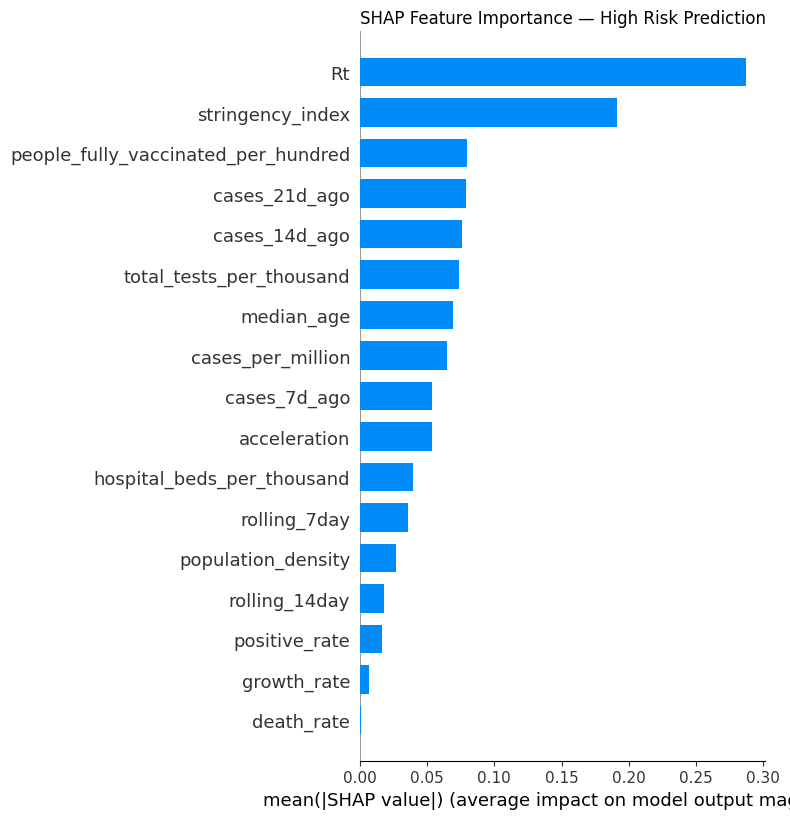

In [75]:

shap_high = shap_values[:, :, 2]

plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_high,
    X_sample,
    feature_names=feature_cols,
    plot_type='bar',
    show=False
)
plt.title("SHAP Feature Importance — High Risk Prediction")
plt.tight_layout()
plt.savefig('shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()


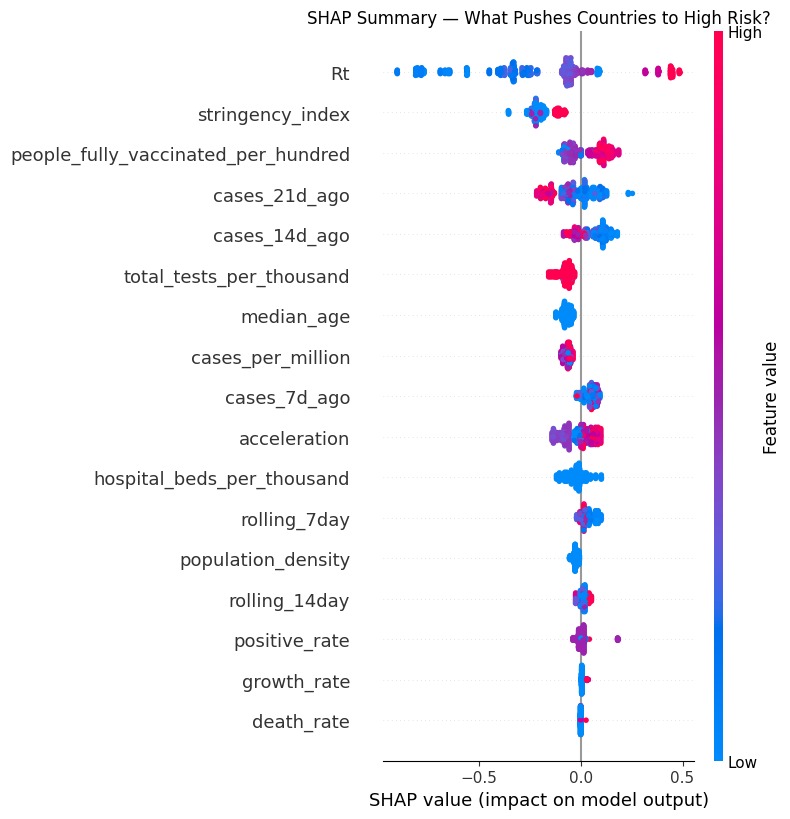

In [76]:
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_high,
    X_sample,
    feature_names=feature_cols,
    show=False
)
plt.title("SHAP Summary — What Pushes Countries to High Risk?")
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()


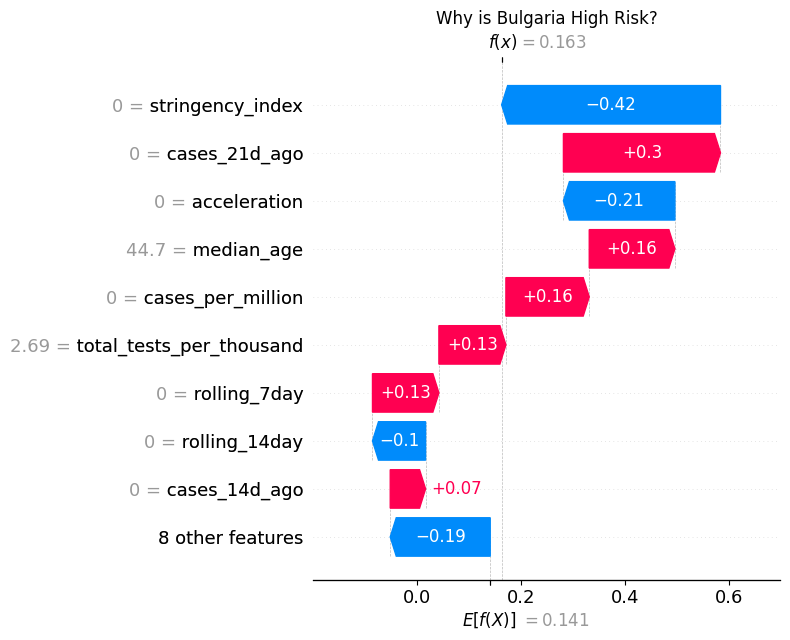

In [77]:
country_name = 'Bulgaria'

country_latest = merged_df[merged_df['location'] == country_name]
country_features = country_latest[feature_cols].replace(
    [np.inf, -np.inf], np.nan
).fillna(0)

country_shap = explainer.shap_values(country_features)

# Shape is (1, 12, 3) — extract High risk
plt.figure(figsize=(10, 4))
shap.waterfall_plot(
    shap.Explanation(
        values=country_shap[0, :, 2],
        base_values=explainer.expected_value[2],
        data=country_features.values[0],
        feature_names=feature_cols
    ),
    show=False
)
plt.title(f"Why is {country_name} High Risk?")
plt.tight_layout()
plt.savefig('shap_country.png', dpi=150, bbox_inches='tight')
plt.show()
